In [1]:
import math
import os
import time
from pathlib import Path
import numpy as np
from operator import itemgetter

import datasets
import torch
from transformers import AutoTokenizer
from torch.optim import AdamW
import torch.nn.functional as F
from gram_newton_schulz import Muon, POLAR_EXPRESS_COEFFICIENTS
from tqdm import tqdm

from nanomoe.data.packed_dataset import PackedPretrainStreamGroup, cu_seqlens_to_packing_metadata
from nanomoe.model import MoEConfig, create_model
from nanomoe.train import unified_loss
from nanomoe.optimizer import build_optimizer_muon, build_optimizer_adamw

from nanomoe.monitors import (
    HiddenStateMonitorResult,
    NeighbourLayerHiddenStateStats,
    TokenHiddenStateLayerStats,
    hidden_state_cosine_similarities
)

%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt

/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
def format_figure(ax, fontsize):
    for a in ax:
        a.grid(
            True,
            which="major",
            color="0.75",
            linewidth=1.0,
            alpha=0.45,
            zorder=0,
        )
        a.set_axisbelow(True)

        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        # Make remaining spines thick and black
        a.spines["left"].set_linewidth(1.0)
        a.spines["bottom"].set_linewidth(1.0)
        a.spines["left"].set_color("black")
        a.spines["bottom"].set_color("black")

        # Tick style: outward, thick, black
        a.tick_params(
            axis="both",
            which="major",
            direction="out",
            length=6,
            width=1.0,
            colors="black",
            pad=1,
            labelsize=fontsize
        )
        a.spines["left"].set_position(("outward", 5))
        a.spines["bottom"].set_position(("outward", 5))

In [3]:
def compute_pretrain_loss(model, batch, aux_loss_coef=0.0, return_router_logits=False):
    batch = batch.to(device, non_blocking=True)
    input_ids = batch.tokens.unsqueeze(0)
    position_ids = batch.position_ids.unsqueeze(0)
    doc_ids, seq_lens = cu_seqlens_to_packing_metadata(batch.cu_seqlens)

    outputs = model(
        input_ids=input_ids,
        position_ids=position_ids,
        packing_doc_ids=doc_ids,
        packing_seq_lens=seq_lens,
        use_cache=False,
        return_router_logits=return_router_logits,
    )

    if batch.labels is None:
        raise ValueError("Packed pretraining batches must include labels.")

    logits = outputs.logits[0]
    lm_loss = unified_loss(logits, batch.labels, batch.token_weights)
    aux_loss = outputs.aux_loss
    if not torch.is_tensor(aux_loss):
        aux_loss = torch.tensor(aux_loss, device=device, dtype=lm_loss.dtype)

    total_loss = lm_loss + aux_loss * aux_loss_coef
    token_count = int(batch.token_weights[:-1].abs().sum().item())
    metrics = {
        "loss": float(lm_loss.detach()),
        "aux_loss": float(aux_loss.detach()),
        "tokens": token_count,
    }

    if return_router_logits:
        router_expert_indices = outputs.router_expert_indices
        entropies = []
        for router_expert_index in router_expert_indices:
            flat = router_expert_index.reshape(-1)
            counts = torch.bincount(flat, minlength=model.config.num_experts).float()
            denom = float(flat.numel())
            if denom == 0.0:
                entropies.append(torch.tensor(float("nan"), device=counts.device))
                continue
            expert_load = counts / denom
            expert_entropy = -(expert_load * torch.log2(expert_load + 1e-12)).sum()
            entropies.append(expert_entropy)
        entropy_t = torch.stack(entropies)
        metrics["expert_entropy"] = float(entropy_t.mean().detach())
        metrics["expert_entropy_by_layer"] = [float(x) for x in entropy_t.detach().cpu().tolist()]

    return total_loss, metrics

In [4]:
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
torch.set_float32_matmul_precision("high")

if not torch.cuda.is_available():
    raise RuntimeError("This notebook is configured for a CUDA GPU, such as one H100.")

device = torch.device("cuda")
dtype = torch.bfloat16

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

dataset_name = "nvidia/Nemotron-CC-Math-v1"
dataset_config = "4plus"
# Use gpt2 tokenizer
tokenizer_name = "gpt2"

seq_len = 65536
max_seq_len = 2048
batch_size = 1          # independent packed streams per optimizer micro-step
grad_accum = 1          # effective tokens/step ~= seq_len * batch_size * grad_accum
max_steps = 100
log_every = 5

lr = 1e-4
weight_decay = 0.1
max_grad_norm = 1.0

print(f"device={device}, dtype={dtype}, torch={torch.__version__}")

device=cuda, dtype=torch.bfloat16, torch=2.10.0+cu128


In [7]:
train_hf_dataset.dataset_size

189231617472

In [8]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)

hf_dataset = datasets.load_dataset(dataset_name, dataset_config, split="train", streaming=True)

val_examples = 1000
train_hf_dataset = hf_dataset.skip(val_examples)
val_hf_dataset = hf_dataset.take(val_examples)

train_dataset = PackedPretrainStreamGroup(
    hf_dataset=train_hf_dataset,
    tokenizer=tokenizer,
    num_streams=batch_size,
    total_shards=batch_size,
    shard_base_index=0,
    seq_len=seq_len,
    max_seq_len=max_seq_len,
    text_key="text",
    min_doc_len=64,
    prefetch_batches=4,
    seed=seed,
    add_special_tokens=False,
 )

val_dataset = PackedPretrainStreamGroup(
    hf_dataset=val_hf_dataset,
    tokenizer=tokenizer,
    num_streams=batch_size,
    total_shards=batch_size,
    shard_base_index=0,
    seq_len=seq_len,
    max_seq_len=max_seq_len,
    text_key="text",
    min_doc_len=64,
    prefetch_batches=4,
    seed=seed,
    add_special_tokens=False,
 )

dataset = train_dataset

In [13]:
def extract_monitor_results(R):
    all_avg_cos = [
        r.mean_off_diagonal_cosine
        for r in R.intra_sequence
    ]
    all_neighbour_layer_stats = [
        (r.mean_token_cosine, r.mean_rms_distance, r.mean_relative_rms_change)
        for r in R.neighbouring_layers
    ]
    all_router_stats = [
        r.entropy for r in R.router_usage_entropy
    ]
    return np.array(all_avg_cos), np.array(all_neighbour_layer_stats), np.array(all_router_stats)


def run_multiple_steps(model, optimizers, steps=50,
                        grad_accum=1, aux_loss_coef=0.0,
                        activate_router_freq=10,
                        return_router_monitor=False):
    # router_monitor = RouterImbalanceMonitor(model)
    data_iter = iter(dataset)
    all_losses = []
    hidden_states_metrics = []
    model.compile()
    for step_id in tqdm(range(steps)):
        with torch.no_grad():
            if step_id % activate_router_freq == 0:
                hidden_states_metrics.append(
                    extract_monitor_results(hidden_state_cosine_similarities(
                        model=model,
                        dataset=iter(val_dataset),
                        batch_size=1,
                        max_batches=1,)
                    ))
        forward_time_start = time.time()
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.zero_grad(set_to_none=True)
        else:
            optimizers.zero_grad(set_to_none=True)
        step_loss = 0.0
        step_aux = 0.0
        step_tokens = 0
        step_router_monitor = []
        for _ in range(grad_accum):
            batch = next(data_iter)
            with torch.autocast(device_type="cuda", dtype=dtype):
                loss, metrics = compute_pretrain_loss(
                    model,
                    batch,
                aux_loss_coef=aux_loss_coef,
                return_router_logits=return_router_monitor)

            (loss / grad_accum).backward()
            step_loss += metrics["loss"]
            step_aux += metrics["aux_loss"]
            step_tokens += metrics["tokens"]
            step_router_monitor += metrics.get("expert_entropy_by_layer", [])
        foward_time = time.time() - forward_time_start
        backward_time_start = time.time()
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.step()
        else:
            optimizers.step()
        backward_time = time.time() - backward_time_start
        all_losses.append(
            {
            "loss": step_loss / grad_accum,
            "aux_loss": step_aux / grad_accum,
            "tokens": step_tokens,
            "forward_time": foward_time,
            "backward_time": backward_time,
            "router_monitor": step_router_monitor
        })
    return all_losses, hidden_states_metrics
    # return router_monitor

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
tokenizer.model_max_length = max_seq_len
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

model = create_model(model_config).to(device=device, dtype=dtype)
model.train()
print(f"model_params={model.num_parameters() / 1e6:.1f}M")
lr = 3e-5
optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_adamw, hidden_states_metrics_adamw_no_scaling = run_multiple_steps(
    model,
    optimizers,
    steps=160,
    activate_router_freq=40,
    return_router_monitor=True,
    grad_accum=10
)

model_params=558.7M


 16%|█████████████████████▋                                                                                                                     | 25/160 [02:29<12:28,  5.55s/it]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

constant = 0.2
alpha = 0.5
residual_scale = constant / (model_config.num_layers ** alpha)
model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.compile()
model.train()
lr = 3e-5
optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_adamw_with_scaling, hidden_states_metrics_adamw_with_scaling = run_multiple_steps(
    model,
    optimizers,
    steps=160,
    activate_router_freq=40,
    return_router_monitor=True,
    grad_accum=10
)

100%|████████████████████████████████████████████████████████| 160/160 [15:19<00:00,  5.75s/it]


In [41]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

constant = 0.2
alpha = 0.5
residual_scale = constant / (model_config.num_layers ** alpha)
model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.compile()
model.train()
lr = 5e-5
optimizers = build_optimizer_muon(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_muon_with_scaling, hidden_states_metrics_muon_with_scaling = run_multiple_steps(
    model,
    optimizers,
    steps=1600,
    activate_router_freq=50,
    return_router_monitor=True
)

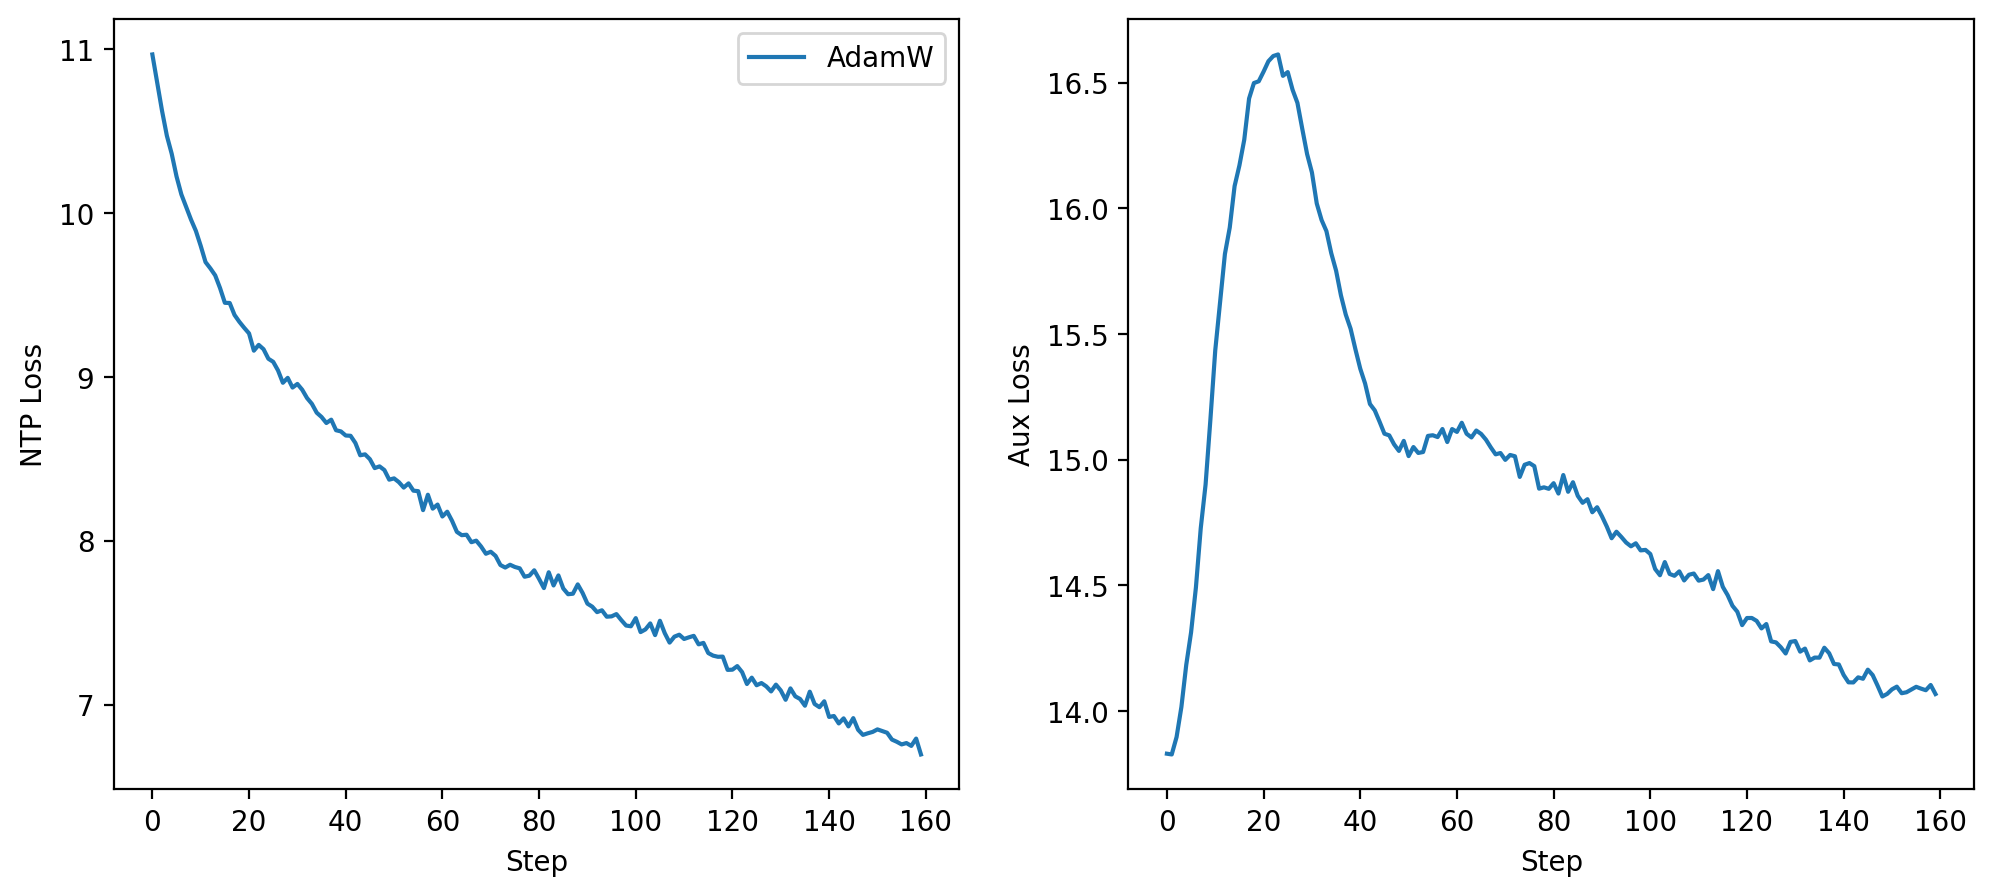

In [19]:
log_dict = {
    'AdamW': log_adamw,
    # 'AdamW with Depth Scaling': log_adamw_with_scaling,
    # 'Muon with Depth Scaling': log_muon_with_scaling,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, log in log_dict.items():
    loss = list(map(itemgetter('loss'), log))
    aux_loss = list(map(itemgetter('aux_loss'), log))
    axes[0].plot(loss, label=name)
    axes[1].plot(aux_loss, label=f"{name} Backward")
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('NTP Loss')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Aux Loss')
axes[0].legend()

IndexError: index 2 is out of bounds for axis 0 with size 2

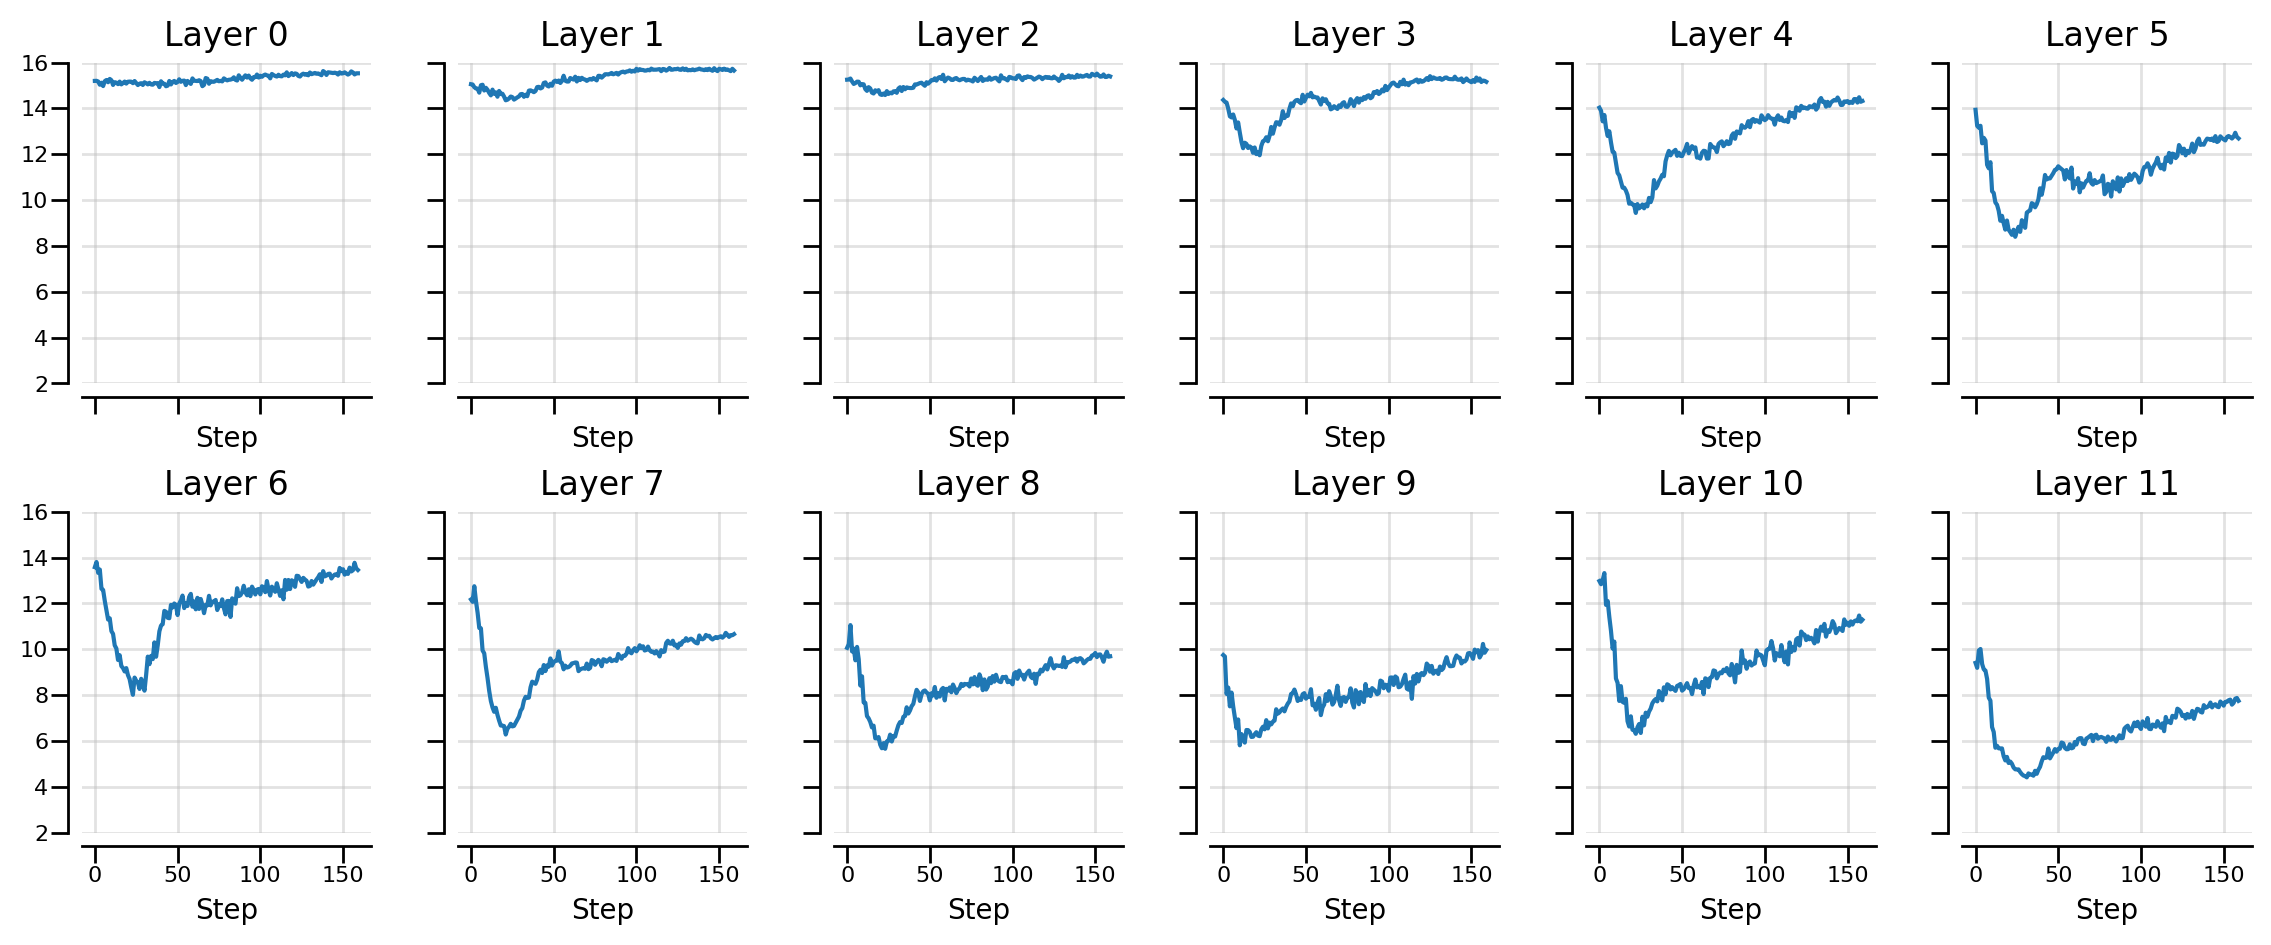

In [20]:
log_dict = {
    'AdamW': log_adamw,
    # 'AdamW with Depth Scaling': log_adamw_with_scaling,
    # 'Muon with Depth Scaling': log_muon_with_scaling,
}

fig, axes = plt.subplots(2, 6, figsize=(14, 5), sharey='row', sharex='col')
fig.subplots_adjust(wspace=0.3, hspace=0.4)
format_figure(axes.flatten(), 8)
for name, log in log_dict.items():
    loss = list(map(itemgetter('loss'), log))
    aux_loss = list(map(itemgetter('router_monitor'), log))
    for i in range(len(aux_loss[0])):
        layer_i_aux_loss = [x[i] for x in aux_loss]
        axes[i // 6, i % 6].plot(2 ** np.array(layer_i_aux_loss), label=name)
        axes[i // 6, i % 6].set_xlabel('Step')
        axes[i // 6, i % 6].set_title(f'Layer {i}')
        # axes[i // 6, i % 6].set_ylim(0, math.log2(model_config.num_experts))
        axes[i // 6, i % 6].set_ylim(2, 16)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1.5), loc='upper left', ncols=2)
axes[0, 0].set_ylabel('Expert usage')
axes[1, 0].set_ylabel('Expert usage')

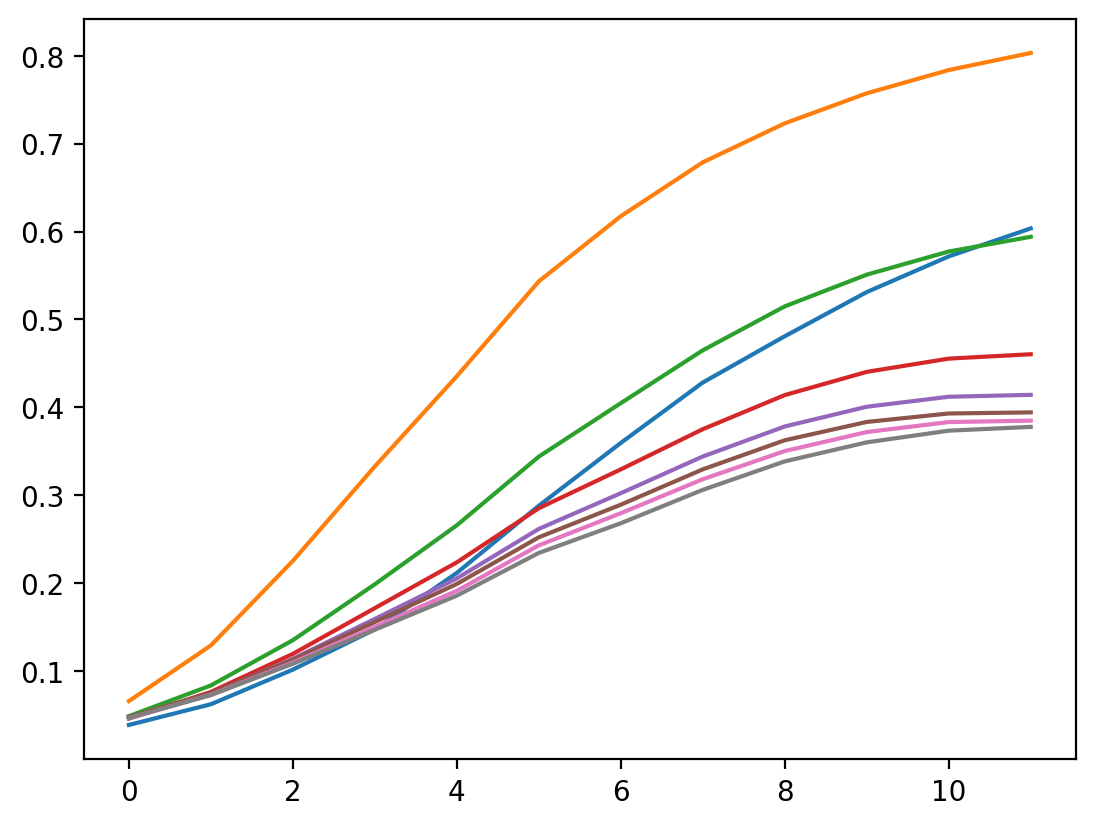

In [52]:
for row in hidden_states_metrics_muon_with_scaling[::4]:
    plt.plot(row[0])

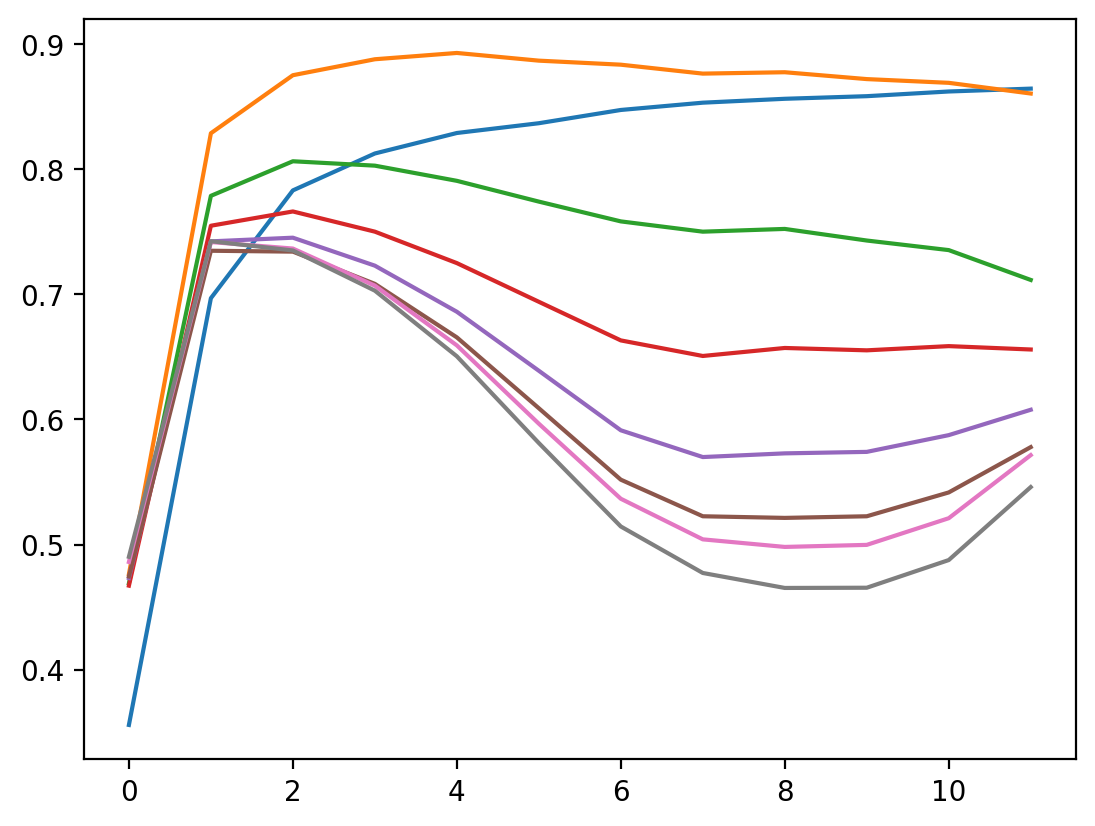

In [51]:
for row in hidden_states_metrics_adamw_no_scaling[::4]:
    plt.plot(row[0])

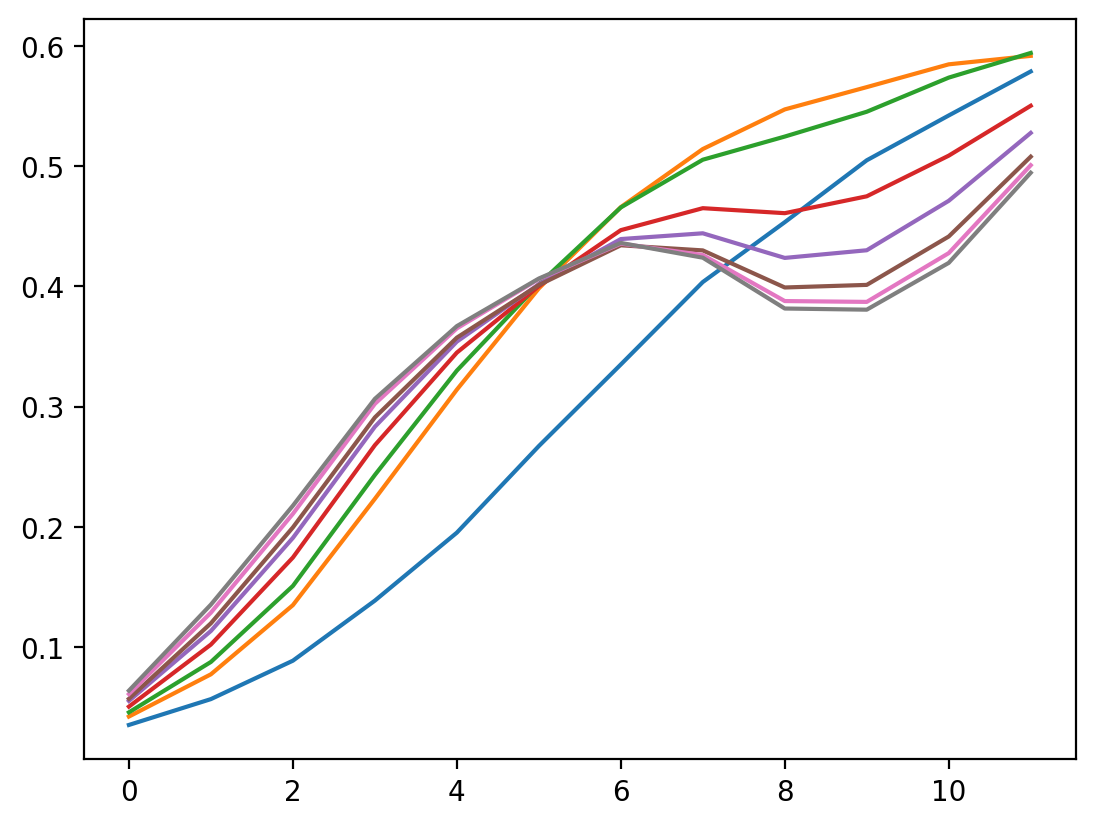

In [50]:
for row in hidden_states_metrics_adamw_with_scaling[::4]:
    plt.plot(row[0])